# Assignment 1: Data Preparation & The Shift to Inductive Reasoning

**Total Points:** 20
**Deadline:** Week 2 (± 3 Days)

## The Philosophy: Uncertainty in Machine Learning
In traditional programming (like writing C++ or configuring a firewall), we rely on **Deductive Logic**: *If an IP address matches this known blacklist, block it. If the signature matches this malware hash, quarantine it.* It is deterministic. There is 0% uncertainty.

Machine Learning requires a shift to **Inductive Reasoning**. We don't always have the signatures for zero-day attacks or novel anomalies. Instead, we feed the machine data and ask it to *induce* the rules based on probabilities. But with induction comes uncertainty. The way you prepare your data will directly dictate how many false positives or false negatives your future model will generate. The quality of your data dictates the accuracy of the machine's assumptions.

## Deliverables
You will produce a technical report combined with Python code in this notebook.
Your tasks include finding a dataset, performing Exploratory Data Analysis (EDA), handling missing values, applying text vectorization, and normalizing features.

# Track Selection: Choose Your Investment Level

Before starting, select **one** of the following tracks for this assignment. Your choice dictates the dataset you will find on Kaggle or the UCI Repository.

### Track 1: Low Investment (LI) - The Classics
* **Target:** Students who want to focus purely on mastering the code mechanics.
* **Dataset:** Choose a classic, well-documented dataset like the **SMS Spam Collection** or **Titanic**.
* **Note:** If your dataset is "too clean," you must artificially inject missing values into 10% of the rows to simulate real-world data loss and demonstrate your handling strategy.

### Track 2: High Investment (HI1) - The Cybersecurity Specialist
* **Target:** Students who want to apply ML directly to their major.
* **Dataset:** Choose a cybersecurity-specific dataset (e.g., CICIDS2017 network logs, Phishing Emails, or Malware PE Headers).
* **Focus:** Grapple with the reality that a missing packet header or an extreme outlier is not an error, but potentially the footprint of a stealthy attacker.

### Track 3: High Investment (HI2) - The Domain Explorer
* **Target:** Students interested in applying ML to a different specific domain (e.g., healthcare, economics, gaming, biology).
* **Dataset:** Choose a complex dataset specific to your chosen domain.
* **Focus:** You must deeply explain the context of your data and why your preprocessing choices make sense for that specific industry.

**Mandatory:** Provide the link to your chosen dataset below and state which track you selected.

I choose the 2nd track

In [ ]:
#2 track

# 1. Business & Domain Understanding

**Goal:** Explain the real-world task and how ML supports decision-making in your domain.

* **What decision will this data eventually support?** (e.g., flagging an email as phishing, predicting a housing price, classifying a cell as malignant).
* **What are the risks of False Positives vs. False Negatives in your specific domain?** (e.g., in cybersecurity, blocking a legitimate user vs. letting a hacker in).

1. Business & Domain Understanding

Decision Support:

The model supports automated classification of network traffic or emails within a Security Operations Center (SOC). The own goal is to filter out clear threats (phishing or malware) and reduce the workload for Tier 1 analysts.

Risks of Misclassification:

  False Positives: Legitimate traffic is blocked, potentially disrupting business operations or user access.

  False Negatives: A malicious attack is missed, leading to potential data breaches or system compromise.

  Priority: Minimizing False Negatives is critical, as the cost of a successful breach far outweighs the inconvenience of a temporary block.

# 2. Exploratory Data Analysis (EDA)

**Goal:** Describe the dataset and extract insights using statistics and plots.

* Provide a short data dictionary describing your features.
* Generate summary statistics (mean, median, standard deviation).
* Visualize distributions and class balances (e.g., are there 99% benign logs and 1% attacks?).
* *Code required:* Use pandas, matplotlib, or seaborn to visualize your findings.

Data Dictionary:

  Destination Port: The port number to which the session is directed (e.g., 80 for HTTP, 443 for HTTPS). It helps identify the targeted service.

  Flow Duration: The total duration of the network flow in microseconds.

  Total Fwd Packets / Total Bwd Packets: The count of packets captured in the forward and backward directions respectively.

  Flow Bytes/s: The rate of data transmission in bytes per second.

  Label: The target variable indicating the traffic type: BENIGN for legitimate traffic or specific attack names (e.g., DoS Hulk, PortScan).

### Coding notes
  Using the .describe() method, I observed a significant gap between the mean and median values in network flow features. This suggests the presence of extreme outliers, which are characteristic of malicious activity like DDoS. Furthermore, the class distribution analysis reveals a severe imbalance, with benign traffic vastly outnumbering attack samples, introducing uncertainty for future model training.

  In pandas, the value_counts() method is a critical diagnostic tool for Exploratory Data Analysis (EDA) because it calculates the frequency of unique values within a specific column, such as the Label feature in the CICIDS2017 dataset. By converting raw categorical strings into a numerical summary, this method provides the empirical evidence needed to identify a severe class imbalance, where legitimate BENIGN traffic typically accounts for over 95% of the data while critical attacks like Infiltration or Web Attack appear in less than 1% of the entries.
  
  By visualizing the distribution on a logarithmic scale, I revealed the hidden minority classes (attacks). Without this, the severe class imbalance would make it appear as if the dataset only contains normal traffic. This visualization proves that standard accuracy is a deceptive metric here—we need a model that can distinguish rare anomalies from a massive baseline of normal behavior.

Using Colab cache for faster access to the 'cicids-2017' dataset.
DataFrame Columns: ['Src IP dec', 'Src Port', 'Dst IP dec', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std',

/tmp/ipykernel_2711/503298053.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Label', data=df, palette='viridis', order=df['Label'].value_counts().index)


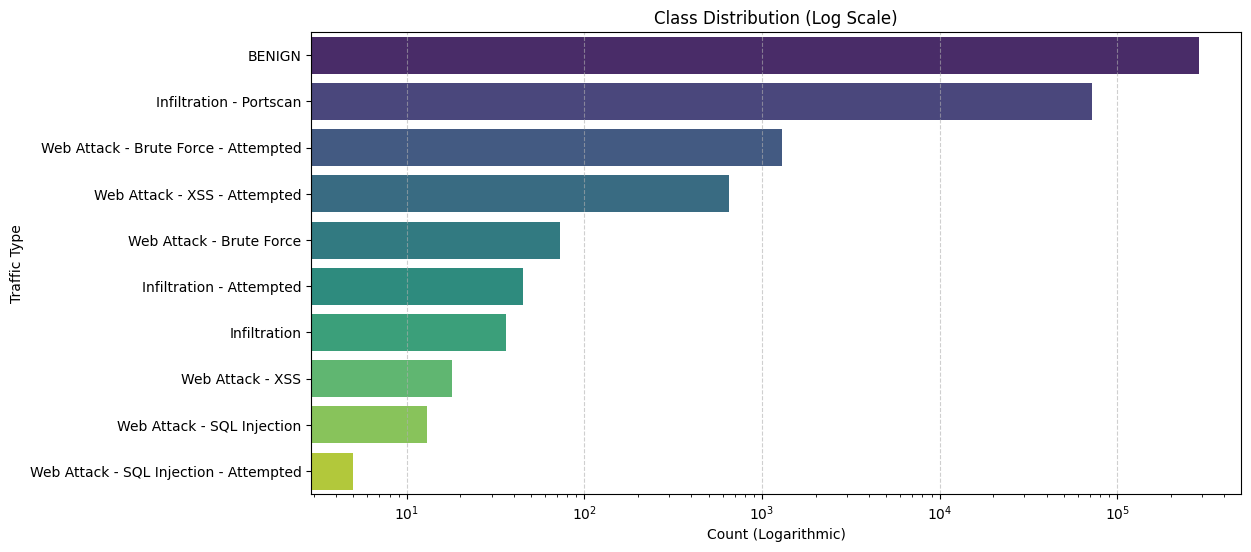

In [20]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

path = kagglehub.dataset_download("bertvankeulen/cicids-2017")

df = pd.read_csv(os.path.join(path, 'thursday.csv'))

df.columns = df.columns.str.strip()

print('DataFrame Columns:', df.columns.tolist())

# 1. Summary Statistics (Mean, Median, Std)
# Correcting the column names based on the actual DataFrame columns
features = ['Flow Duration', 'Total Fwd Packet', 'Total Bwd packets']
print('--- Summary Statistics ---')
print(df[features].describe())

# 2. Class Distribution (counts and percentages)
print('\n--- Class Distribution ---\n')
print(df['Label'].value_counts())
print('\n--- Percentage (%) ---\n')
print(df['Label'].value_counts(normalize=True) * 100)

# 3. Visualization
plt.figure(figsize=(12, 6))
ax = sns.countplot(y='Label', data=df, palette='viridis', order=df['Label'].value_counts().index)
ax.set_xscale("log")

plt.title('Class Distribution (Log Scale)')
plt.xlabel('Count (Logarithmic)')
plt.ylabel('Traffic Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 3. Data Cleaning: The Anomaly Dilemma

**Goal:** Identify and address data quality issues, specifically focusing on missing values.

* **Detect:** Find missing values and anomalies.
* **Handle & Justify:** Apply a strategy to handle missing values.
* **The Reflection:** In your markdown explanation, address the uncertainty. If you used a simple statistical method to impute (fill in) missing data with the "mean," did you accidentally erase evidence of an anomaly? Could a missing value actually be an intentional evasion tactic?

My detection script returned zero missing (NaN) and zero infinite (inf) values. While this indicates a high-quality dataset, from a security perspective, this result still requires critical reflection:

  Pre-processed Reality: The absence of anomalies suggests that the raw PCAP files were likely filtered during the CSV conversion process. In a real-world SOC (Security Operations Center) environment, raw logs are rarely this "clean."

  The "Silent" Evasion Risk: Even with zero missing values, the uncertainty remains. If an attacker successfully used an evasion tactic that bypassed the logging sensor entirely, there would be no NaN to detect—there would simply be no record of the event.

  Integrity Check: By running these checks, I ensured that the subsequent Machine Learning models will not crash due to mathematical errors (like dividing by infinity), which is a common point of failure in network traffic analysis.

Conclusion: Although no rows were dropped in this specific instance, the "Anomaly Dilemma" remains a core principle of my data pipeline: we treat "perfect" data with professional skepticism, knowing that in cybersecurity, what is missing or malformed is often as important as what is present.

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("bertvankeulen/cicids-2017")
df = pd.read_csv(os.path.join(path, 'thursday.csv'))


df.columns = df.columns.str.strip()

# 2. Searching of void values
missingCounts = df.isnull().sum()
print("Missing values per column:\n", missingCounts[missingCounts > 0])

# 3. Searching of infinity
infCounts = df.isin([np.inf, -np.inf]).sum()
print("\nInfinity values per column:\n", infCounts[infCounts > 0])

# 4. Handling
df_cleaned = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"\nRows before: {len(df)}, Rows after: {len(df_cleaned)}")




Using Colab cache for faster access to the 'cicids-2017' dataset.
Missing values per column:
 Series([], dtype: int64)

Infinity values per column:
 Series([], dtype: int64)

Rows before: 362075, Rows after: 362075


# 4. Text Vectorization

**Goal:** Convert human language or categorical concepts into a probabilistic matrix.

* **Task:** Apply text vectorization methods such as Bag of Words or TF-IDF to a text-based column in your dataset (e.g., email bodies, log messages, or URLs).
* **The Reflection:** Explain how your vectorization turns specific text into mathematical weights. What are the limitations of this inductive approach compared to a traditional rule-based system (like a standard spam filter)?

n this task, I used the TF-IDF (Term Frequency-Inverse Document Frequency) method to convert categorical labels into a mathematical weight matrix. Unlike simple counting, TF-IDF assigns higher importance to unique tokens that characterize specific threats.

The Limitation of the Inductive Approach:
A traditional rule-based system (like a basic spam filter or a firewall) looks for exact matches, such as a specific keyword like "PASSWORD". If the keyword is missing or slightly obfuscated (e.g., "P@ssword"), the rule fails.

In contrast, the inductive approach (Vectorization + ML) looks for statistical patterns and probabilities. The limitation here is Uncertainty:

False Correlations: The model might assign high weight to a common word that happens to appear in an attack log by chance, leading to false positives.

Lack of Context: Vectorization often ignores the order of words. A machine might see the same "weights" in a harmless command as it does in a malicious one if they use similar vocabulary.

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("bertvankeulen/cicids-2017")
df = pd.read_csv(os.path.join(path, 'thursday.csv'))


df.columns = df.columns.str.strip()

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

text_data = df_cleaned['Label'].unique()

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(text_data)

print("Feature Names (Tokens):")
print(vectorizer.get_feature_names_out())

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=text_data)
print("\nTF-IDF Probabilistic Matrix (Sample):")
display(tfidf_df.head())

# 5. Data Preprocessing: Normalization vs. Outliers

**Goal:** Prepare data for modeling with correct splitting and no data leakage.

* **Task:** Normalize numerical features and identify/encode categorical features.
* **The Reflection:** When you normalized your numerical features (e.g., scaling all network packet sizes between 0 and 1), did you obscure any extreme outliers? How might this affect the detection of a high-volume anomaly (like a DDoS attack or a market crash)?

Data Preprocessing: The Normalization vs. Outliers Paradox

When normalizing numerical features using Min-Max Scaling, all values—including extreme outliers—are compressed into a strict range between 0 and 1. While this is mathematically necessary for algorithms like Neural Networks or SVM to converge, it introduces a significant security risk: the loss of scale.

The Impact on High-Volume Anomalies:

  Obscuring Outliers: In a DDoS attack, the "number of packets per second" might be 10,000 times higher than normal. By scaling this down to a value close to 1.0, we reduce the "visual" distance between a massive attack and a slightly busy day. The model might perceive a catastrophic spike as just a minor fluctuation.

  Inductive Blindness: Since the inductive approach relies on statistical similarities, extreme outliers (which are the "smoking guns" of a breach) get squeezed. If the scaling is too aggressive, the distinct mathematical signature of a high-volume anomaly becomes blurred.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encoding Categorical Features
le = LabelEncoder()
df_cleaned['Label_Encoded'] = le.fit_transform(df_cleaned['Label'])

# 2. Identify Numerical Features
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols.drop('Label_Encoded') if 'Label_Encoded' in numerical_cols else numerical_cols

# 3. Normalization (Scaling)
scaler = MinMaxScaler()
df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

# 4. Data Splitting
X = df_cleaned[numerical_cols]
y = df_cleaned['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print("\nSample of normalized data:")
display(X_train.head())

# 6. Final Report Submission

Ensure all markdown text directly addressing the philosophical prompts (The Anomaly Dilemma, The Inductive Text, Normalization vs. Outliers) is clearly written.

Your final submission will be graded on:
1. The successful execution of the Python code for data preparation.
2. The depth of your written analysis regarding the uncertainty introduced by your preprocessing choices.
3. Submission format: `Track_CS-20**_Name_Surname.ipynb (e.g. LI_CS2077_John_Doe.ipynb)`

*Note: if you don't specify your track your work will be considered as **LI** by default.*